## 1. Set up environment

In [1]:
%%capture
# %% [1] Cài đặt môi trường
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    import torch; v = re.match(r"[0-9]{1,}\.[0-9]{1,}", str(torch.__version__)).group(0)
    xformers = "xformers==" + ("0.0.33.post1" if v=="2.9" else "0.0.32.post2" if v=="2.8" else "0.0.29.post3")
    !pip install --no-deps bitsandbytes accelerate {xformers} peft trl triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth

!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2
!pip install jiwer einops addict easydict

## 2. Load base model

In [2]:
# %% [2] Load Model & Tokenizer
from unsloth import FastVisionModel
from transformers import AutoModel
import torch
import os

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# Tải snapshot model về local để load nhanh hơn
from huggingface_hub import snapshot_download
snapshot_download("unsloth/DeepSeek-OCR", local_dir = "deepseek_ocr")

os.environ["UNSLOTH_WARN_UNINITIALIZED"] = '0'

model, tokenizer = FastVisionModel.from_pretrained(
    "./deepseek_ocr",
    load_in_4bit = True, # Khuyên dùng False (16bit) cho OCR để chính xác hơn
    auto_model = AutoModel,
    trust_remote_code=True,
    unsloth_force_compile=True,
    use_gradient_checkpointing = "unsloth",
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


2025-12-28 06:54:04.881315: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766904845.234107      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766904845.355366      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766904846.171069      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766904846.171106      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766904846.171109      24 computation_placer.cc:177] computation placer alr

🦥 Unsloth Zoo will now patch everything to make training faster!


.gitattributes: 0.00B [00:00, ?B/s]

README-checkpoint.md: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.


Unsloth: WARNING `trust_remote_code` is True.
Are you certain you want to do remote code execution?
==((====))==  Unsloth 2025.12.9: Fast Deepseekocr patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.4.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.
You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.
Some weights of DeepseekOCRForCausalLM were not initialized from the model checkpoint at ./deepseek_ocr and are newly initialized: ['model.vision_model.embeddings.position_ids']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## 3. Load and preprocess data

In [3]:
# %% [3] Xử lý Data
from datasets import load_from_disk, concatenate_datasets
import math
import os

# --- CẤU HÌNH ĐƯỜNG DẪN & CACHE ---
DATASET_PATH = "/kaggle/input/uit-data-preprocessed" 
# Ép cache của HuggingFace vào thư mục working để có quyền ghi
CACHE_DIR = "/kaggle/working/hf_cache"
os.makedirs(CACHE_DIR, exist_ok=True)
os.environ["HF_DATASETS_CACHE"] = CACHE_DIR

print("⏳ Đang load dataset từ đĩa...")
try:
    full_dataset = load_from_disk(DATASET_PATH)
    print("✅ Load dataset gốc thành công:", full_dataset)
except Exception as e:
    print("❌ Lỗi load dataset!", e)
    raise e

# --- HÀM LẤY MẪU THEO TỶ LỆ ---
def get_stratified_subset(dataset, total_count, split_name="train", seed=42):
    """
    Hàm lấy mẫu theo tỷ lệ: Word (30%), Line (30%), Paragraph (40%)
    Đã fix lỗi Read-only bằng cách dùng keep_in_memory=True
    """
    ratios = {'word': 0.3, 'line': 0.3, 'paragraph': 0.4}
    subsets = []
    
    print(f"\n🎯 Đang trích xuất {total_count} mẫu cho tập {split_name} (30-30-40):")
    
    for dtype, ratio in ratios.items():
        # Lọc dữ liệu và giữ trên RAM để tránh ghi file vào thư mục Input
        ds_type = dataset.filter(
            lambda x: x['type'] == dtype, 
            keep_in_memory=True
        )
        
        target_n = int(total_count * ratio)
        actual_n = min(len(ds_type), target_n)
        
        print(f"   - {dtype.title()}: Cần {target_n}, Có {len(ds_type)} -> Lấy {actual_n}")
        
        if actual_n > 0:
            # Dùng keep_in_memory=True để không tạo file cache trên ổ đĩa Read-only
            subset = ds_type.shuffle(seed=seed, keep_in_memory=True).select(range(actual_n), keep_in_memory=True)
            subsets.append(subset)
    
    if not subsets:
        # Trả về dataset rỗng nếu không có dữ liệu
        return dataset.select(range(0), keep_in_memory=True)
        
    final_ds = concatenate_datasets(subsets)
    return final_ds.shuffle(seed=seed, keep_in_memory=True)

# 1. Xử lý tập Test (100 ảnh)
print("✂️ Đang xử lý tập Test...")
test_dataset = get_stratified_subset(full_dataset['test'], total_count=100, split_name="test")

# 2. Xử lý tập Train Subset (2000 ảnh)
print("✂️ Đang xử lý tập Train...")
train_subset = get_stratified_subset(full_dataset['train'], total_count=2000, split_name="train")

# 3. Chia Train/Validate (90% - 10%)
total_samples = len(train_subset)
val_size = int(0.1 * total_samples)
train_size = total_samples - val_size

# Đảm bảo các bước cắt nhỏ cũng dùng RAM
train_dataset = train_subset.select(range(train_size), keep_in_memory=True)
eval_dataset = train_subset.select(range(train_size, total_samples), keep_in_memory=True)

print("-" * 40)
print(f"📊 Thống kê cuối cùng: Train: {len(train_dataset)} | Val: {len(eval_dataset)} | Test: {len(test_dataset)}")

⏳ Đang load dataset từ đĩa...


Loading dataset from disk:   0%|          | 0/108 [00:00<?, ?it/s]

✅ Load dataset gốc thành công: DatasetDict({
    train: Dataset({
        features: ['image', 'text', 'type'],
        num_rows: 115748
    })
    test: Dataset({
        features: ['image', 'text', 'type'],
        num_rows: 3113
    })
})
✂️ Đang xử lý tập Test...

🎯 Đang trích xuất 100 mẫu cho tập test (30-30-40):


Filter:   0%|          | 0/3113 [00:00<?, ? examples/s]

   - Word: Cần 30, Có 2881 -> Lấy 30


...

   - Word: Cần 600, Có 107607 -> Lấy 600


Filter:   0%|          | 0/115748 [00:00<?, ? examples/s]

   - Line: Cần 600, Có 7028 -> Lấy 600


Filter:   0%|          | 0/115748 [00:00<?, ? examples/s]

   - Paragraph: Cần 800, Có 1113 -> Lấy 800
----------------------------------------
📊 Thống kê cuối cùng: Train: 1800 | Val: 200 | Test: 91


In [4]:
# %% [4] Hàm chuẩn bị dữ liệu
import torch
import math
import os
from dataclasses import dataclass
from typing import Dict, List, Any, Tuple
from PIL import Image, ImageOps
from torch.nn.utils.rnn import pad_sequence
import io
from deepseek_ocr.modeling_deepseekocr import (
    format_messages, text_encode, BasicImageTransform, dynamic_preprocess,
)

# --- TẠO FOLDER CACHE RIÊNG TRONG VÙNG GHI ĐƯỢC ---
CACHE_DIR = "/kaggle/working/hf_map_cache"
if not os.path.exists(CACHE_DIR):
    os.makedirs(CACHE_DIR)
print(f"📂 Đã tạo cache dir tại: {CACHE_DIR}")

instruction = "<image>\nFree OCR. "

def convert_to_conversation(sample):
    conversation = [
        {"role": "<|User|>", "content": instruction, "images": [sample['image']]},
        {"role": "<|Assistant|>", "content": sample["text"]},
    ]
    return {"messages": conversation}

# Convert datasets
print("🔄 Đang convert format dữ liệu (sẽ tốn chút thời gian)...")

# 1. Convert Train
print("   - Mapping train set...")
train_dataset = train_dataset.map(
    convert_to_conversation, 
    remove_columns=train_dataset.column_names,
    cache_file_name=os.path.join(CACHE_DIR, "train_mapped.arrow") 
)

# 2. Convert Eval
print("   - Mapping eval set...")
eval_dataset = eval_dataset.map(
    convert_to_conversation, 
    remove_columns=eval_dataset.column_names,
    cache_file_name=os.path.join(CACHE_DIR, "eval_mapped.arrow")
)

print(f"✅ Convert xong! Train: {len(train_dataset)}, Eval: {len(eval_dataset)}")

# --- Data Collator ---
@dataclass
class DeepSeekOCRDataCollator:
    tokenizer: Any
    model: Any
    image_size: int = 640
    base_size: int = 1024
    crop_mode: bool = True
    image_token_id: int = 128815
    train_on_responses_only: bool = True

    def __init__(self, tokenizer, model, image_size=640, base_size=1024, crop_mode=True, train_on_responses_only=True):
        self.tokenizer = tokenizer
        self.model = model
        self.image_size = image_size
        self.base_size = base_size
        self.crop_mode = crop_mode
        self.image_token_id = 128815
        self.dtype = model.dtype
        self.train_on_responses_only = train_on_responses_only
        self.image_transform = BasicImageTransform(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5), normalize=True)
        self.patch_size = 16
        self.downsample_ratio = 4
        self.bos_id = tokenizer.bos_token_id if hasattr(tokenizer, 'bos_token_id') else 0

    def deserialize_image(self, image_data) -> Image.Image:
        if isinstance(image_data, Image.Image): return image_data.convert("RGB")
        elif isinstance(image_data, dict) and 'bytes' in image_data: return Image.open(io.BytesIO(image_data['bytes'])).convert("RGB")
        raise ValueError(f"Unsupported image format: {type(image_data)}")

    def process_image(self, image: Image.Image):
        images_list, images_crop_list, images_spatial_crop = [], [], []
        if self.crop_mode:
            if image.size[0] <= 640 and image.size[1] <= 640:
                crop_ratio = (1, 1); images_crop_raw = []
            else:
                images_crop_raw, crop_ratio = dynamic_preprocess(image, min_num=1, max_num=2, image_size=self.image_size, use_thumbnail=False)
            global_view = ImageOps.pad(image, (self.base_size, self.base_size), color=tuple(int(x*255) for x in self.image_transform.mean))
            images_list.append(self.image_transform(global_view).to(self.dtype))
            width_crop_num, height_crop_num = crop_ratio
            images_spatial_crop.append([width_crop_num, height_crop_num])
            if width_crop_num > 1 or height_crop_num > 1:
                for crop_img in images_crop_raw: images_crop_list.append(self.image_transform(crop_img).to(self.dtype))
            num_queries = math.ceil((self.image_size // self.patch_size) / self.downsample_ratio)
            num_queries_base = math.ceil((self.base_size // self.patch_size) / self.downsample_ratio)
            tokenized_image = ([self.image_token_id] * num_queries_base + [self.image_token_id]) * num_queries_base + [self.image_token_id]
            if width_crop_num > 1 or height_crop_num > 1:
                tokenized_image += ([self.image_token_id] * (num_queries * width_crop_num) + [self.image_token_id]) * (num_queries * height_crop_num)
        else:
            crop_ratio = (1, 1); images_spatial_crop.append([1, 1])
            if self.base_size <= 640: images_list.append(self.image_transform(image.resize((self.base_size, self.base_size), Image.LANCZOS)).to(self.dtype))
            else: images_list.append(self.image_transform(ImageOps.pad(image, (self.base_size, self.base_size), color=tuple(int(x*255) for x in self.image_transform.mean))).to(self.dtype))
            num_queries = math.ceil((self.base_size // self.patch_size) / self.downsample_ratio)
            tokenized_image = ([self.image_token_id] * num_queries + [self.image_token_id]) * num_queries + [self.image_token_id]
        return images_list, images_crop_list, images_spatial_crop, tokenized_image, crop_ratio

    def process_single_sample(self, messages: List[Dict]) -> Dict[str, Any]:
        images = []
        for message in messages:
            if "images" in message and message["images"]:
                for img_data in message["images"]: images.append(self.deserialize_image(img_data))
        tokenized_str, images_seq_mask, images_list, images_crop_list, images_spatial_crop = [self.bos_id], [False], [], [], []
        prompt_token_count, assistant_started, image_idx = -1, False, 0
        for message in messages:
            role, content = message["role"], message["content"]
            if role == "<|Assistant|>":
                if not assistant_started: prompt_token_count = len(tokenized_str); assistant_started = True
                content = f"{content.strip()} {self.tokenizer.eos_token}"
            text_splits = content.split('<image>')
            for i, text_sep in enumerate(text_splits):
                tokenized_sep = text_encode(self.tokenizer, text_sep, bos=False, eos=False)
                tokenized_str.extend(tokenized_sep); images_seq_mask.extend([False] * len(tokenized_sep))
                if i < len(text_splits) - 1:
                    img_list, crop_list, spatial_crop, tok_img, _ = self.process_image(images[image_idx])
                    images_list.extend(img_list); images_crop_list.extend(crop_list); images_spatial_crop.extend(spatial_crop)
                    tokenized_str.extend(tok_img); images_seq_mask.extend([True] * len(tok_img)); image_idx += 1
        if not assistant_started: prompt_token_count = len(tokenized_str)
        images_ori = torch.stack(images_list, dim=0); images_spatial_crop_tensor = torch.tensor(images_spatial_crop, dtype=torch.long)
        images_crop = torch.stack(images_crop_list, dim=0) if images_crop_list else torch.zeros((1, 3, self.base_size, self.base_size), dtype=self.dtype)
        return {"input_ids": torch.tensor(tokenized_str, dtype=torch.long), "images_seq_mask": torch.tensor(images_seq_mask, dtype=torch.bool), "images_ori": images_ori, "images_crop": images_crop, "images_spatial_crop": images_spatial_crop_tensor, "prompt_token_count": prompt_token_count}

    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        batch_data = [self.process_single_sample(f['messages']) for f in features]
        input_ids = pad_sequence([x['input_ids'] for x in batch_data], batch_first=True, padding_value=self.tokenizer.pad_token_id)
        images_seq_mask = pad_sequence([x['images_seq_mask'] for x in batch_data], batch_first=True, padding_value=False)
        labels = input_ids.clone(); labels[labels == self.tokenizer.pad_token_id] = -100; labels[images_seq_mask] = -100
        if self.train_on_responses_only:
            for idx, cnt in enumerate([x['prompt_token_count'] for x in batch_data]):
                if cnt > 0: labels[idx, :cnt] = -100
        attention_mask = (input_ids != self.tokenizer.pad_token_id).long()
        images_batch = [(x['images_crop'], x['images_ori']) for x in batch_data]
        images_spatial_crop = torch.cat([x['images_spatial_crop'] for x in batch_data], dim=0)
        return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels, "images": images_batch, "images_seq_mask": images_seq_mask, "images_spatial_crop": images_spatial_crop}

📂 Đã tạo cache dir tại: /kaggle/working/hf_map_cache
🔄 Đang convert format dữ liệu (sẽ tốn chút thời gian)...
   - Mapping train set...


Map:   0%|          | 0/1800 [00:00<?, ? examples/s]

   - Mapping eval set...


Map:   0%|          | 0/200 [00:00<?, ? examples/s]

✅ Convert xong! Train: 1800, Eval: 200


## 4. Evaluate Base model


🚀 Đang chạy đánh giá 91 mẫu...


Processing:   0%|          | 0/91 [00:00<?, ?it/s]The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.



📸 --- MẪU KIỂM TRA 0 ---
Kết quả OCR: cho giào duc - đào tạo.


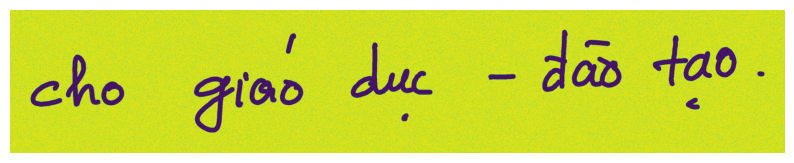

Processing: 100%|██████████| 91/91 [31:24<00:00, 20.71s/it]


✅ HOÀN TẤT! Avg WER: 1.1309 | Avg CER: 1.4032


In [5]:
# %% [5] Đánh giá Base model
import matplotlib.pyplot as plt
from jiwer import wer, cer
from tqdm import tqdm
import pandas as pd
import numpy as np
import os
import io
from contextlib import redirect_stdout

# --- CẤU HÌNH HỆ THỐNG ---
NUM_TEST_SAMPLES = len(test_dataset)
OUTPUT_CSV = "report_base_model.csv"

# 1. SET GIỚI HẠN CỨNG VÀO CONFIG
# Việc này giúp mô hình tự ngắt sau 300 token mà không cần truyền tham số vào hàm infer
if hasattr(model, 'generation_config'):
    model.generation_config.max_new_tokens = 300
    model.generation_config.pad_token_id = tokenizer.pad_token_id
    model.generation_config.eos_token_id = tokenizer.eos_token_id

def evaluate_and_report(model, tokenizer, dataset, num_samples, csv_path, visual_idx=0):
    results = []
    wer_list = []
    cer_list = []
    
    # Ngưỡng ký tự để xác định lặp (Tiếng Việt 300 token thường khoảng 1000-1200 ký tự)
    # Nếu dài hơn 1500 ký tự thì chắc chắn là lặp vô nghĩa
    MAX_CHAR_THRESHOLD = 1500 

    print(f"\n🚀 Đang chạy đánh giá {num_samples} mẫu...")
    
    for i in tqdm(range(num_samples), desc="Processing"):
        sample = dataset[i]
        ground_truth = str(sample['text']).strip()
        temp_path = f"temp_eval_{i}.jpg"
        sample['image'].save(temp_path)
        
        try:
            f = io.StringIO()
            with redirect_stdout(f):
                # Gọi hàm infer thuần túy, không thêm tham số lạ
                returned_value = model.infer(
                    tokenizer, 
                    prompt="<image>\nFree OCR. ", 
                    image_file=temp_path,
                    base_size=1024, 
                    image_size=640, 
                    crop_mode=True, 
                    save_results=False, 
                    output_path="./"
                )
            
            captured_output = f.getvalue().strip().split('\n')
            clean_lines = [line for line in captured_output if not any(x in line for x in ["torch.Size", "Processing", "BASE:", "PATCHES:"])]
            
            # Lấy kết quả dự đoán
            if returned_value is not None and str(returned_value).strip() != "":
                clean_pred = str(returned_value).strip()
            else:
                clean_pred = clean_lines[-1].strip() if clean_lines else ""

            # 2. KIỂM TRA LẶP DÀI: Nếu quá ngưỡng thì coi như không đọc được (trả về "")
            if len(clean_pred) > MAX_CHAR_THRESHOLD:
                # print(f"\n⚠️ Mẫu {i} bị lặp quá dài ({len(clean_pred)} ký tự). Đã xóa kết quả.")
                clean_pred = ""
            
            # Tính toán metrics
            curr_wer = wer(ground_truth, clean_pred)
            curr_cer = cer(ground_truth, clean_pred)
            
            wer_list.append(curr_wer)
            cer_list.append(curr_cer)
            results.append({
                "id": i, "ground_truth": ground_truth, "prediction": clean_pred,
                "wer": curr_wer, "cer": curr_cer
            })
            
            if i == visual_idx:
                print(f"\n📸 --- MẪU KIỂM TRA {i} ---")
                print(f"Kết quả OCR: {clean_pred if clean_pred else '[BỊ XÓA DO LẶP]'}")
                plt.figure(figsize=(10, 4))
                plt.imshow(sample['image'])
                plt.axis('off')
                plt.show()
        
        except Exception as e:
            print(f"❌ Lỗi tại mẫu {i}: {e}")
        finally:
            if os.path.exists(temp_path): os.remove(temp_path)

    avg_wer, avg_cer = np.mean(wer_list), np.mean(cer_list)
    print(f"\n✅ HOÀN TẤT! Avg WER: {avg_wer:.4f} | Avg CER: {avg_cer:.4f}")
    
    df = pd.DataFrame(results)
    df.to_csv(csv_path, index=False, encoding='utf-8-sig')
    return df

# Chạy đánh giá
df_base = evaluate_and_report(model, tokenizer, test_dataset, NUM_TEST_SAMPLES, OUTPUT_CSV)

## 5. Finetune

In [6]:
# %% [6] Setup Finetune (LoRA)
model = FastVisionModel.get_peft_model(
    model,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    r = 16,
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,
    loftq_config = None,
)

FastVisionModel.for_training(model)

# %% [7] Training Arguments
from transformers import Trainer, TrainingArguments, TrainerCallback
from unsloth import is_bf16_supported
import torch
import pandas as pd
from IPython.display import display, clear_output

# Cấu hình bước lưu (Save Steps)
PER_DEVICE_BATCH_SIZE = 1
GRAD_ACCUMULATION = 16
SAVE_STEPS = 20 
print(f"💾 Cấu hình: Lưu checkpoint mỗi {SAVE_STEPS} steps.")

# --- CLASS LOG PANDAS  ---
class PandasLogCallback(TrainerCallback):
    def __init__(self):
        self.history = [] # Dùng list để lưu lịch sử
        
    def on_log(self, args, state, control, logs=None, **kwargs):
        # Lấy step hiện tại
        current_step = state.global_step
        
        # 1. Tìm xem step này đã có trong bảng chưa
        # (Vì Trainer bắn log Train riêng và Eval riêng, nên cần gộp lại)
        row = next((item for item in self.history if item["Step"] == current_step), None)
        
        if row is None:
            # Nếu chưa có dòng này thì tạo mới
            row = {
                "Step": current_step,
                "Epoch": round(logs.get("epoch", 0), 2),
                "Train Loss": logs.get("loss", None),
                "Val Loss": logs.get("eval_loss", None),
                "LR": logs.get("learning_rate", None)
            }
            self.history.append(row)
        else:
            # Nếu đã có dòng này rồi thì update thêm dữ liệu thiếu (ví dụ điền thêm Val Loss)
            if "loss" in logs: row["Train Loss"] = logs["loss"]
            if "eval_loss" in logs: row["Val Loss"] = logs["eval_loss"]
            if "epoch" in logs: row["Epoch"] = round(logs["epoch"], 2)
            if "learning_rate" in logs: row["LR"] = logs["learning_rate"]

        # 2. Vẽ lại bảng
        # Chỉ vẽ khi có dữ liệu mới để tránh nháy màn hình quá nhiều
        clear_output(wait=True)
        print("🚀 Training Progress (Real-time):")
        
        # Tạo DataFrame từ list history
        df = pd.DataFrame(self.history)
        
        # Sắp xếp lại cột cho đẹp
        cols = ["Step", "Epoch", "Train Loss", "Val Loss", "LR"]
        # Đảm bảo chỉ hiện các cột có trong dữ liệu
        cols = [c for c in cols if c in df.columns] 
        
        display(df[cols].tail(10)) # Chỉ hiện 10 dòng cuối

# --- Cấu hình Data Collator  ---
data_collator = DeepSeekOCRDataCollator(
    tokenizer=tokenizer,
    model = model,
    image_size=512,
    base_size=768, 
    crop_mode=True,
    train_on_responses_only=True,
)

# Dọn dẹp bộ nhớ trước khi train
torch.cuda.empty_cache()
import gc
gc.collect()

trainer = Trainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = data_collator,
    train_dataset = train_dataset,
    eval_dataset = eval_dataset, 
    args = TrainingArguments(
        per_device_train_batch_size = PER_DEVICE_BATCH_SIZE,
        gradient_accumulation_steps = GRAD_ACCUMULATION,
        per_device_eval_batch_size = 1,      
        eval_accumulation_steps = 1,
        warmup_steps = 50,
        num_train_epochs = 3,
        
        # --- Cấu hình lưu ---
        save_strategy = "steps",
        save_steps = SAVE_STEPS,
        save_total_limit = 2,     
        
        # --- Cấu hình Eval ---
        eval_strategy = "steps",
        eval_steps = SAVE_STEPS,
        
        gradient_checkpointing = True,
        learning_rate = 2e-4,
        logging_steps = 10,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        fp16 = not is_bf16_supported(),
        bf16 = is_bf16_supported(),
        output_dir = "outputs_deepseek_ocr",
        report_to = "none",
        dataloader_num_workers = 2,
        remove_unused_columns = False,
        load_best_model_at_end = True,
        metric_for_best_model = "eval_loss",
    ),
    callbacks=[PandasLogCallback()] # Gọi callback mới
)

print("✅ Đã setup Trainer!")


# %% [8] Bắt đầu Train
print("🚀 Bắt đầu quá trình Finetune...")
trainer_stats = trainer.train()

🚀 Training Progress (Real-time):


,Step,Epoch,Train Loss,Val Loss,LR
8,90,1.59,0.6673,NaN,0.000136
9,100,1.76,0.6092,0.625581,0.000119
10,110,1.94,0.5348,NaN,0.000102
11,120,2.11,0.5002,0.613437,0.000086
12,130,2.28,0.4237,NaN,0.000069
13,140,2.46,0.4026,0.594019,0.000053
14,150,2.64,0.3937,NaN,0.000036
15,160,2.82,0.4348,0.576631,0.000020
16,170,3.00,0.3847,NaN,0.000003
17,171,3.00,NaN,NaN,NaN


## 6. Evaluate Finetune model

🔍 Đánh giá Finetuned Model trên toàn bộ Test Set...

🚀 Đang chạy đánh giá 91 mẫu...


Processing:   0%|          | 0/91 [00:00<?, ?it/s]


📸 --- MẪU KIỂM TRA 0 ---
Kết quả OCR: cho giáo dục - đào tạo.


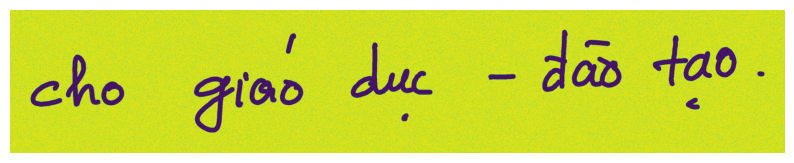

Processing: 100%|██████████| 91/91 [55:47<00:00, 36.79s/it] 


✅ HOÀN TẤT! Avg WER: 0.4750 | Avg CER: 0.2844

BẢNG SO SÁNH HIỆU QUẢ:
Character Error Rate (CER)
   🔹 Base Model:      1.4032
   🔹 Finetuned Model: 0.2844
   🚀 Cải thiện:       79.73% (Giảm lỗi)
----------------------------------------
Word Error Rate (WER)
   🔹 Base Model:      1.1309
   🔹 Finetuned Model: 0.4750
   🚀 Cải thiện:       58.00% (Giảm lỗi)


In [7]:
# %% [9] Evaluate Finetuned Model: Visual, CSV Report & Full Metrics
print("🔍 Đánh giá Finetuned Model trên toàn bộ Test Set...")

# 1. Chuyển model sang chế độ Inference (QUAN TRỌNG)
FastVisionModel.for_inference(model)

# --- CẤU HÌNH ---
NUM_TEST_SAMPLES = len(test_dataset) 
OUTPUT_CSV = "report_finetuned_model.csv"

# 2. Tái sử dụng hàm evaluate_and_report 
if 'evaluate_and_report' in globals():
    df_finetune = evaluate_and_report(
        model, 
        tokenizer, 
        test_dataset, 
        NUM_TEST_SAMPLES, 
        OUTPUT_CSV, 
        visual_idx=0 # Visual lại ảnh đầu tiên để so sánh
    )
    
    # --- SO SÁNH KẾT QUẢ CHI TIẾT (CER & WER) ---
    if 'df_base' in globals():
        # --- Tính toán CER ---
        base_cer = df_base['cer'].mean()
        fine_cer = df_finetune['cer'].mean()
        imp_cer = ((base_cer - fine_cer) / base_cer) * 100 if base_cer > 0 else 0
        
        # --- Tính toán WER ---
        base_wer = df_base['wer'].mean()
        fine_wer = df_finetune['wer'].mean()
        imp_wer = ((base_wer - fine_wer) / base_wer) * 100 if base_wer > 0 else 0
        
        print("\nBẢNG SO SÁNH HIỆU QUẢ:")
        print("=" * 40)
        
        # In CER
        print("Character Error Rate (CER)")
        print(f"   🔹 Base Model:      {base_cer:.4f}")
        print(f"   🔹 Finetuned Model: {fine_cer:.4f}")
        if imp_cer > 0:
            print(f"   🚀 Cải thiện:       {imp_cer:.2f}% (Giảm lỗi)")
        else:
            print(f"   🔻 Suy giảm:        {imp_cer:.2f}%")
            
        print("-" * 40)
        
        # In WER
        print("Word Error Rate (WER)")
        print(f"   🔹 Base Model:      {base_wer:.4f}")
        print(f"   🔹 Finetuned Model: {fine_wer:.4f}")
        if imp_wer > 0:
            print(f"   🚀 Cải thiện:       {imp_wer:.2f}% (Giảm lỗi)")
        else:
            print(f"   🔻 Suy giảm:        {imp_wer:.2f}%")
            
        print("=" * 40)
    else:
        print("\n⚠️ Không tìm thấy kết quả Base Model (df_base) để so sánh.")
else:
    print("⚠️ Lỗi: Chưa chạy Cell 5 để load hàm đánh giá. Vui lòng chạy lại Cell 5 trước.")

## 7. Save Model

In [8]:
# %% [10] Save Model cuối cùng
print("💾 Đang lưu model cuối cùng...")
model.save_pretrained("lora_model_final")
tokenizer.save_pretrained("lora_model_final")
print("🎉 Hoàn tất!")

💾 Đang lưu model cuối cùng...


You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.


🎉 Hoàn tất!
